# Mount project from Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Set project path

In [2]:
import sys
import os

PROJECT_PATH = "/content/drive/MyDrive/ai_service"  # adjust if needed
sys.path.append(PROJECT_PATH)

os.chdir(PROJECT_PATH)
print("Current dir:", os.getcwd())

Current dir: /content/drive/MyDrive/ai_service


# Install dependencies

In [3]:
!pip install scikit-learn pandas numpy joblib opencv-python paho-mqtt mediapipe

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.2/67.2 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 63.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 7.8 MB/s eta 0:00:00
  Attempting uninstall: absl-py
    Found existing installation: absl-py 1.4.0
    Uninstalling absl-py-1.4.0:
      Successfully uninstalled absl-py-1.4.0


# Import modules

In [4]:
import numpy as np
import pandas as pd
import glob
import joblib

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder

from utils.preprocessing import preprocess

# Load dataset

In [5]:
import os
import glob
import numpy as np
import pandas as pd


DATA_PATH = "data"


def load_from_folder(folder_path):
    X_list = []
    y_list = []

    files = glob.glob(os.path.join(folder_path, "*.csv"))

    print(f"📂 Found {len(files)} files")

    for file in files:
        label = os.path.splitext(os.path.basename(file))[0]

        # ==============================
        # SAFE LOAD
        # ==============================
        if os.path.getsize(file) == 0:
            print(f"⚠️ Skipping empty file: {file}")
            continue

        try:
            df = pd.read_csv(file)
        except Exception as e:
            print(f"⚠️ Failed to read {file}: {e}")
            continue

        if df.empty:
            print(f"⚠️ Skipping empty dataframe: {file}")
            continue

        data = df.values

        print(f"✅ {label}: {data.shape}")

        X_list.append(data)
        y_list.extend([label] * len(data))

    # ==============================
    # STACK
    # ==============================
    if not X_list:
        raise ValueError("❌ No valid data found")

    X = np.vstack(X_list)
    y = np.array(y_list)

    return X, y


# ==============================
# LOAD DATA
# ==============================
X, y = load_from_folder(DATA_PATH)

print("\n📊 Dataset summary:")
print("Samples:", len(X))
print("Features per sample:", X.shape[1])

# Class distribution
unique, counts = np.unique(y, return_counts=True)
for u, c in zip(unique, counts):
    print(f"{u}: {c}")

📂 Found 6 files
✅ open_palm: (42, 63)
✅ fist: (42, 63)
✅ peace: (42, 63)
✅ four_fingers: (42, 63)
✅ thumbs_up: (42, 63)
✅ thumbs_down: (42, 63)

📊 Dataset summary:
Samples: 252
Features per sample: 63
fist: 42
four_fingers: 42
open_palm: 42
peace: 42
thumbs_down: 42
thumbs_up: 42


# Preprocess

In [6]:
USE_2D = False

X_processed = np.array([
    preprocess(x, use_2d=USE_2D) for x in X
])

print("Shape:", X_processed.shape)

Shape: (252, 63)


# Encode labels

In [7]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print(label_encoder.classes_)

['fist' 'four_fingers' 'open_palm' 'peace' 'thumbs_down' 'thumbs_up']


# Split

In [9]:
X_train, X_val, y_train, y_val = train_test_split(
    X_processed,
    y_encoded,
    test_size=0.2,
    stratify=y_encoded,
    random_state=42
)

print(f'X_train shape: {X_train.shape}')
print(f'X_val shape: {X_val.shape}')
print(f'y_train shape: {y_train.shape}')
print(f'y_val shape: {y_val.shape}')

X_train shape: (201, 63)
X_val shape: (51, 63)
y_train shape: (201,)
y_val shape: (51,)


# Train SVM

In [16]:
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, GridSearchCV

# Build model
svm = SVC(probability=True)

# Hyperparameter
param_grid = {
    "kernel": ['rbf', 'linear'],
    "C": [0.1, 1, 10, 100],
    "gamma": ["scale", 'auto']
}


# Stratified K-Fold
kf_cv = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=42 # To support for reproducibility
)

# Grid Search
grid_search = GridSearchCV(
    estimator=svm,
    param_grid=param_grid,
    cv=kf_cv,
    scoring="f1_macro",   # good for imbalanced data
    n_jobs=-1, # -1: all processors; 1: 1 processors except special cases
    verbose=2 # msg displayed
)

# Fit GridSearchCV on the training data
print("Performing stratified 10-fold cross-validation for hyperparameter tuning...")
grid_search.fit(X_train, y_train)

# Get the best parameters and best score
print(f"Best parameters found: {grid_search.best_params_}")
print(f"Best cross-validation F1-score: {grid_search.best_score_:.4f}")

#model = SVC(
#    kernel="rbf",
#    C=10,
#    gamma="scale",
#    probability=True
#)

#model.fit(X_train, y_train)

Performing stratified 10-fold cross-validation for hyperparameter tuning...
Fitting 10 folds for each of 16 candidates, totalling 160 fits
Best parameters found: {'C': 100, 'gamma': 'scale', 'kernel': 'rbf'}
Best cross-validation F1-score: 1.0000


# Evaluate

In [17]:
# Get the best model
best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_val)

acc = accuracy_score(y_val, y_pred)
print("Accuracy:", acc)

print("\nClassification Report:")
print(classification_report(
    y_val,
    y_pred,
    target_names=label_encoder.classes_
))

Accuracy: 0.9803921568627451

Classification Report:
              precision    recall  f1-score   support

        fist       1.00      1.00      1.00         8
four_fingers       1.00      0.88      0.93         8
   open_palm       0.90      1.00      0.95         9
       peace       1.00      1.00      1.00         9
 thumbs_down       1.00      1.00      1.00         9
   thumbs_up       1.00      1.00      1.00         8

    accuracy                           0.98        51
   macro avg       0.98      0.98      0.98        51
weighted avg       0.98      0.98      0.98        51



# Save model

In [18]:
os.makedirs("models", exist_ok=True)

joblib.dump(best_model, "models/gesture_model.pkl")
joblib.dump(label_encoder, "models/label_encoder.pkl")

print("Model saved!")

Model saved!


# Class distribution

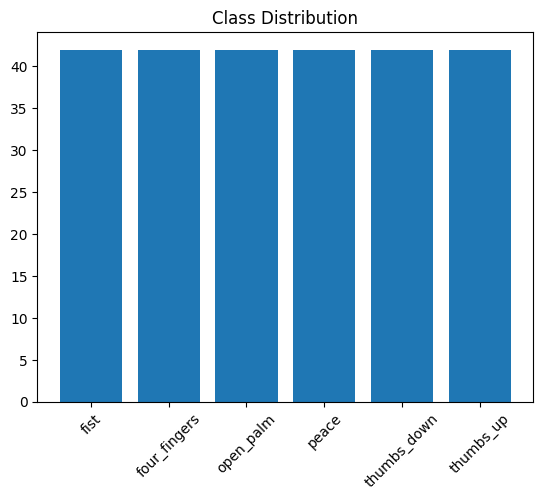

In [19]:
import matplotlib.pyplot as plt

unique, counts = np.unique(y, return_counts=True)
plt.bar(unique, counts)
plt.xticks(rotation=45)
plt.title("Class Distribution")
plt.show()

```python
collect_gestures.py → data/
        ↓
Colab notebook → training & tuning
        ↓
models/
        ↓
gesture_infer.py → real-time system
```